Model MIMO mass spring damper system,
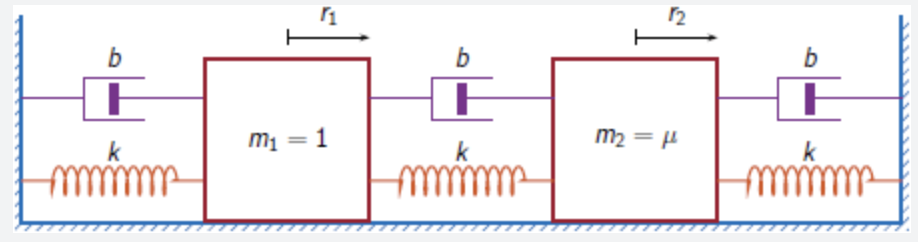

In [7]:
import numpy as np
from scipy import signal
from scipy.linalg import inv
import matplotlib.pyplot as plt

# Parameters
mu = 2.0
k = 50.0
b = 0.8

# Matrices
M = np.array([[1.0, 0.0],
              [0.0, mu]])

C = np.array([[2*b, -b],
              [-b, 2*b]])

K = np.array([[2*k, -k],
              [-k, 2*k]])




Convert to statespace model


In [8]:
n = 2
Z = np.zeros((n,n))
I = np.eye(n)

Minv = inv(M)

A = np.block([
    [Z, I],
    [-Minv @ K, -Minv @ C]
])

B = np.vstack([
    np.zeros((n,n)),
    Minv
])

Cout = np.hstack([I, Z])
D = np.zeros((2,2))

sys = signal.StateSpace(A, B, Cout, D)
print(sys)

StateSpaceContinuous(
array([[   0. ,    0. ,    1. ,    0. ],
       [   0. ,    0. ,    0. ,    1. ],
       [-100. ,   50. ,   -1.6,    0.8],
       [  25. ,  -50. ,    0.4,   -0.8]]),
array([[ 0. ,  0. ],
       [ 0. ,  0. ],
       [ 1. , -0. ],
       [ 0. ,  0.5]]),
array([[1., 0., 0., 0.],
       [0., 1., 0., 0.]]),
array([[0., 0.],
       [0., 0.]]),
dt: None
)


Simulate inputs u using lsim which returns the system response y to the input u , sampled at the same times t as the input

1000
1000


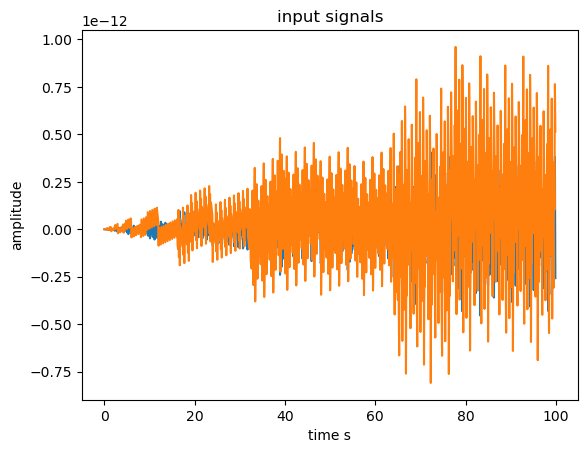

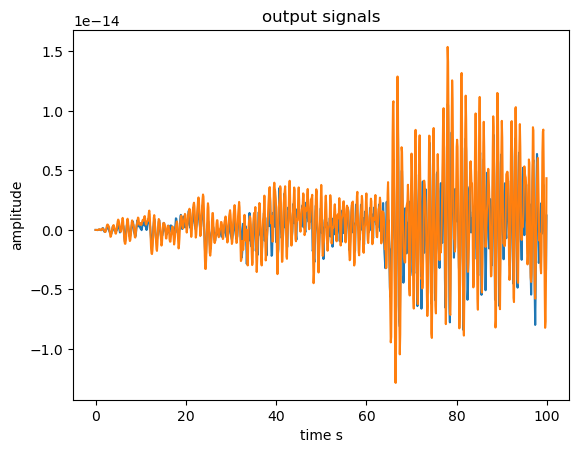

In [9]:
fs = 10
T = 100
t = np.arange(0, T, 1/fs)
N = len(t)



u1 = (np.sin(2*np.pi*5*t))


u2 = np.sin(2*np.pi*10*t)

u = np.column_stack((u1, u2))
print(len(u))
t_out, y, x = signal.lsim(sys, u, t)
plt.figure()
plt.plot(t,u1)
plt.plot(t,u2)
plt.xlabel("time s")
plt.ylabel("amplitude")
plt.title("input signals")

plt.figure()
plt.plot(t,y)
plt.xlabel("time s")
plt.ylabel("amplitude")
plt.title("output signals")
print(N)

#print(u)

Calculate out put using analytical transfer function from frequency input

In [10]:
def H_true(omega):
    jw = 1j * omega
    return inv(jw**2 * M + jw*C + K)

Use DFT to Estimate U(s) and Y(s) and find estimated transfer function

In [11]:
U = np.fft.fft(u)
print(U[0])
print(U[1])

Y = np.fft.fft(y)
print(Y[0])
print(Y[1])
# 2. Calculate the transfer function H(f) = Y(f) / U(f)
# Be cautious of division by zero (or very small values) if the input has no energy at certain frequencies.
# A common approach in practice is to use spectral division with some form of regularization or
# to use the cross-spectral density method for noise robustness (not shown here).
H = np.divide(Y, U, where=U!=0, out=np.zeros_like(Y))

# 3. Get the corresponding frequency bins

freqs = np.fft.fftfreq(N, 1/fs)
omega = 2*np.pi*freqs


# We typically only care about the positive frequencies for real-valued signals
# The spectrum is symmetric (Hermitian symmetric) for real inputs
n_oneside = N // 2
f_oneside = freqs[:n_oneside]
H_oneside = H[:n_oneside]
print(H)

[0.+0.j 0.+0.j]
[-1.2246468e-16+0.j  3.6739404e-16+0.j]
[0.+0.j 0.+0.j]
[-1.26566415e-20+0.j  3.69506370e-19+0.j]
[[ 0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 1.03349321e-04-0.j  1.00574950e-03+0.j]
 [ 1.40750636e-03-0.j  6.85166369e-03+0.j]
 ...
 [-2.31132530e-01+0.j -2.14991958e-02-0.j]
 [-5.84657817e-03+0.j -3.91020175e-04-0.j]
 [ 2.15336321e-02+0.j  4.04718133e-03-0.j]]


Compare with analytical DFT

<function H_true at 0x7fc068d91f70>


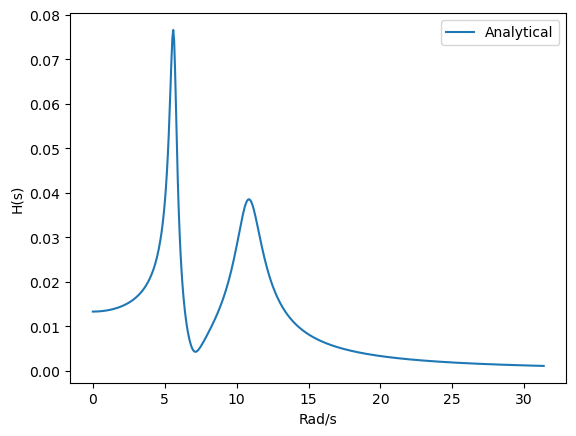

[0j, (0.00010334932081196711-0j), (0.0014075063597964166-0j), (-0.003641447869529912+0j), (0.0050949003706873604-0j), (0.011095610761680546-0j), (0.0009135859299263405+0j), (0.018655947853925804+0j), (-0.026158501824637366-0j), (-0.06788366531015774-0j), (-0.014912572611131202-0j), (0.0018771740656673434+0j), (-0.002172231363160173+0j), (0.0035746682351939225+0j), (0.005536337160341791+0j), (-0.0405532801417141-0j), (-0.047220393258202306-0j), (-0.003001349221537147-0j), (0.03690164764401226-0j), (-0.01769557077037275+0j), (-0.008486679770350992+0j), (0.004809986309673632+0j), (0.06550254952992969+0j), (0.020724585840709644+0j), (0.03210837278648165+0j), (-0.005006982106127818-0j), (0.030214716956738316-0j), (0.045318592447985716-0j), (-0.09724277812230725+0j), (0.08508862173549611-0j), (0.019495452186358415-0j), (0.07055768294573225+0j), (-0.04220944103148914-0j), (0.027426866932273194+0j), (0.00836477919114604+0j), (0.018014102821779537-0j), (-0.010625445531388536+0j), (-0.0048421070

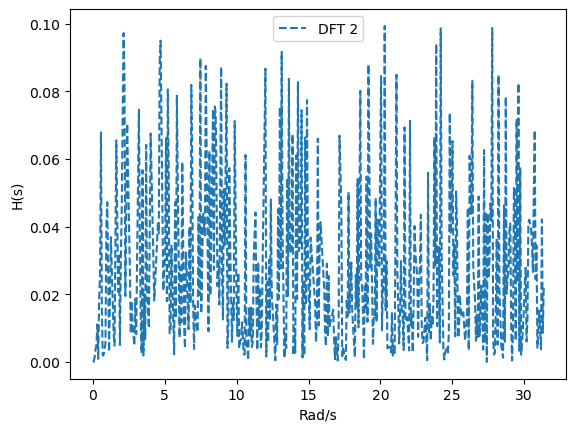

In [12]:

omega_pos = omega[:N//2]
H_oneside = H[0,:N//2]
print(np.array(H_true))

H_exact = np.array([H_true(w) for w in omega_pos])

#print(H_exact)
H_fft = H[:N//2]




plt.plot(omega_pos, np.abs(H_exact[:,0,0]), label="Analytical")

plt.legend()
plt.xlabel("Rad/s")
plt.ylabel("H(s)")
plt.show()


threshold = 0.1
omega_actual = []
H_actual = []
#print(H_fft)
for w in range(len(omega_pos)):
  if np.abs(H_fft[w,0]) < threshold:
    H_actual.append(H_fft[w,0])
    omega_actual.append(omega_pos[w])
print(H_actual)
print(omega_actual)




plt.figure()
#plt.plot(omega_pos, np.abs(H_fft[:,0]), '--', label="DFT")
plt.plot(omega_actual, np.abs(H_actual), '--', label="DFT 2")
#plt.plot( omega_pos[valid],np.abs(H_fft[:, 0][valid]),'--',label="DFT")
plt.legend()
plt.xlabel("Rad/s")
plt.ylabel("H(s)")
plt.show()

todo: make nyquist plot of transfer function. do a siso msd with the pkl data. estimate transfer function parameters ie wn, m, c, k, zeta using least squares regression.